In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dec19 = pd.read_csv(r"C:\Users\Aditi\Desktop\Data_Analytics\Raw\2019-Dec.csv")
nov19 = pd.read_csv(r"C:\Users\Aditi\Desktop\Data_Analytics\Raw\2019-Nov.csv")
oct19 = pd.read_csv(r"C:\Users\Aditi\Desktop\Data_Analytics\Raw\2019-Oct.csv")
jan20 = pd.read_csv(r"C:\Users\Aditi\Desktop\Data_Analytics\Raw\2020-Jan.csv")
feb20 = pd.read_csv(r"C:\Users\Aditi\Desktop\Data_Analytics\Raw\2020-Feb.csv")



df = pd.concat(
    [dec19,nov19,oct19,jan20,feb20],
    ignore_index=True
)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [4]:
df.drop_duplicates(inplace=True)



In [6]:
df= df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    19240810
brand             8265149
price                   0
user_id                 0
user_session         4085
dtype: int64

In [9]:
df['brand']=df['brand'].fillna('unknown')

In [10]:
df['category_code']=df['category_code'].fillna('unknown')

In [12]:
df['user_session']=df['user_session'].fillna('none')

In [13]:
df.isna().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64

In [14]:
df['event_time']=pd.to_datetime(df['event_time'], utc=True)

In [15]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00+00:00,remove_from_cart,5712790,1487580005268456287,unknown,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00+00:00,view,5764655,1487580005411062629,unknown,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02+00:00,cart,4958,1487580009471148064,unknown,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05+00:00,view,5848413,1487580007675986893,unknown,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07+00:00,view,5824148,1487580005511725929,unknown,unknown,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [17]:
df['date']=df['event_time'].dt.date
df['time']=df['event_time'].dt.tz_convert('Asia/Kolkata').dt.time
df['year']=df['event_time'].dt.year
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,time,year
0,2019-12-01 00:00:00+00:00,remove_from_cart,5712790,1487580005268456287,unknown,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc,2019-12-01,05:30:00,2019
1,2019-12-01 00:00:00+00:00,view,5764655,1487580005411062629,unknown,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18,2019-12-01,05:30:00,2019
2,2019-12-01 00:00:02+00:00,cart,4958,1487580009471148064,unknown,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019-12-01,05:30:02,2019
3,2019-12-01 00:00:05+00:00,view,5848413,1487580007675986893,unknown,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4,2019-12-01,05:30:05,2019
4,2019-12-01 00:00:07+00:00,view,5824148,1487580005511725929,unknown,unknown,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,2019-12-01,05:30:07,2019


In [18]:
df= df.sort_values(by='event_time')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,time,year
8169123,2019-10-01 00:00:00+00:00,cart,5773203,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,05:30:00,2019
8169124,2019-10-01 00:00:03+00:00,cart,5773353,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,05:30:03,2019
8169125,2019-10-01 00:00:07+00:00,cart,5881589,2151191071051219817,unknown,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,05:30:07,2019
8169126,2019-10-01 00:00:07+00:00,cart,5723490,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,05:30:07,2019
8169127,2019-10-01 00:00:15+00:00,cart,5881449,1487580013522845895,unknown,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,05:30:15,2019


In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 19583742 entries, 8169123 to 20692839
Data columns (total 12 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
 9   date           object             
 10  time           object             
 11  year           int32              
dtypes: datetime64[us, UTC](1), float64(1), int32(1), int64(3), object(2), str(4)
memory usage: 1.8+ GB


In [22]:
df['date']=pd.to_datetime(df['date'])

df.info()

<class 'pandas.DataFrame'>
Index: 19583742 entries, 8169123 to 20692839
Data columns (total 12 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
 9   date           datetime64[s]      
 10  time           object             
 11  year           int32              
dtypes: datetime64[s](1), datetime64[us, UTC](1), float64(1), int32(1), int64(3), object(1), str(4)
memory usage: 1.8+ GB


In [23]:
df.drop(columns=['time'], inplace=True)

In [24]:
df['time']=df['event_time'].dt.tz_convert('Asia/Kolkata').dt.strftime('%I:%M %p')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,time
8169123,2019-10-01 00:00:00+00:00,cart,5773203,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM
8169124,2019-10-01 00:00:03+00:00,cart,5773353,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM
8169125,2019-10-01 00:00:07+00:00,cart,5881589,2151191071051219817,unknown,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM
8169126,2019-10-01 00:00:07+00:00,cart,5723490,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM
8169127,2019-10-01 00:00:15+00:00,cart,5881449,1487580013522845895,unknown,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM


In [28]:
df_clean=df[df['brand']!='unknown']
df_clean.groupby('brand')['price'].nunique()

brand
airnails     35
almea        23
andrea        3
ardell       69
arganoil      7
           ... 
ypsed        20
yu-r          9
zab           7
zeitun      167
zinger      132
Name: price, Length: 273, dtype: int64

In [29]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,time
8169123,2019-10-01 00:00:00+00:00,cart,5773203,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM
8169124,2019-10-01 00:00:03+00:00,cart,5773353,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM
8169125,2019-10-01 00:00:07+00:00,cart,5881589,2151191071051219817,unknown,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM
8169126,2019-10-01 00:00:07+00:00,cart,5723490,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM
8169127,2019-10-01 00:00:15+00:00,cart,5881449,1487580013522845895,unknown,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM


In [31]:
df.shape

(19583742, 12)

In [35]:
df['event_time'].dt.hour.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23], dtype=int32)

In [33]:
df['date'].dt.isocalendar().week.unique()

<IntegerArray>
[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 1, 2, 3, 4, 5, 6, 7, 8,
 9]
Length: 22, dtype: UInt32

In [36]:
df.tail(3)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,time
20692837,2020-02-29 23:59:45+00:00,view,5850628,1602943681873052386,unknown,grattol,5.24,622090043,ab7d349f-db5d-4790-8ab1-31e5c894459d,2020-02-29,2020,05:29 AM
20692838,2020-02-29 23:59:54+00:00,view,5716351,1487580010872045658,unknown,irisk,0.79,619841242,18af673b-7fb9-4202-a66d-5c855bc0fd2d,2020-02-29,2020,05:29 AM
20692839,2020-02-29 23:59:59+00:00,view,5927709,1487580013950664926,unknown,de.lux,3.17,621669991,daa3c677-5360-4327-847e-d29658716b99,2020-02-29,2020,05:29 AM


In [37]:
df['hour'] = df['event_time'].dt.hour

df['time_range'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

In [38]:
df['week'] = df['date'].dt.isocalendar().week

df['week_range'] = pd.cut(
    df['week'],
    bins=[0, 4, 8, 13, 26, 39, 52],
    labels=[
        'W1-W4',
        'W5-W8',
        'W9-W13',
        'W14-W26',
        'W27-W39',
        'W40-W52'
    ]
)


df.head()



,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,time,hour,time_range,week,week_range
8169123,2019-10-01 00:00:00+00:00,cart,5773203,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM,0,Night,40,W40-W52
8169124,2019-10-01 00:00:03+00:00,cart,5773353,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM,0,Night,40,W40-W52
8169125,2019-10-01 00:00:07+00:00,cart,5881589,2151191071051219817,unknown,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM,0,Night,40,W40-W52
8169126,2019-10-01 00:00:07+00:00,cart,5723490,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM,0,Night,40,W40-W52
8169127,2019-10-01 00:00:15+00:00,cart,5881449,1487580013522845895,unknown,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM,0,Night,40,W40-W52


In [39]:
df.drop(columns=['hour', 'time_range'], inplace=True)

In [40]:
df['time_range'] = pd.cut(
    df['event_time'].dt.hour,
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,time,week,week_range,time_range
8169123,2019-10-01 00:00:00+00:00,cart,5773203,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM,40,W40-W52,Night
8169124,2019-10-01 00:00:03+00:00,cart,5773353,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM,40,W40-W52,Night
8169125,2019-10-01 00:00:07+00:00,cart,5881589,2151191071051219817,unknown,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM,40,W40-W52,Night
8169126,2019-10-01 00:00:07+00:00,cart,5723490,1487580005134238553,unknown,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01,2019,05:30 AM,40,W40-W52,Night
8169127,2019-10-01 00:00:15+00:00,cart,5881449,1487580013522845895,unknown,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01,2019,05:30 AM,40,W40-W52,Night


In [41]:
df['time_range'].unique()

['Night', 'Morning', 'Afternoon', 'Evening']
Categories (4, str): ['Night' < 'Morning' < 'Afternoon' < 'Evening']

In [43]:
df_powerbi = df.copy()
df_powerbi = df.drop(
    columns=['product_id','category_id','category_code','user_id','user_session']
)

df_powerbi.to_csv(r"C:\Users\Aditi\Desktop\Data_Analytics\PowerBI\powerbi.csv", index=False)

In [44]:
df.to_csv(r"C:\Users\Aditi\Desktop\Data_Analytics\Excel\cleaned.csv",index=False)
print("done")

done


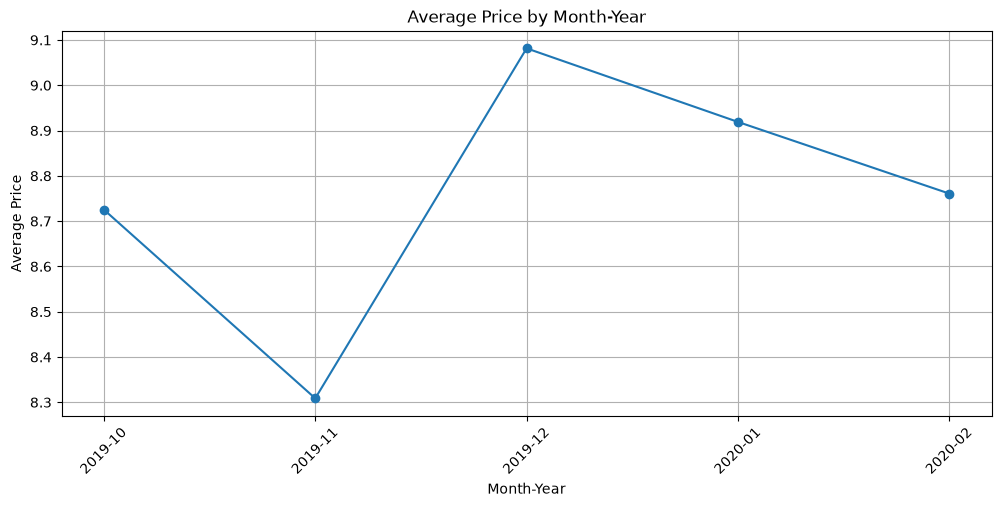

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Create month-year column
df['month_year'] = df['date'].dt.to_period('M').astype(str)

# Calculate average price per month
monthly_avg_price = df.groupby('month_year')['price'].mean().reset_index()

# Plot
plt.figure(figsize=(12,5))

plt.plot(
    monthly_avg_price['month_year'],
    monthly_avg_price['price'],
    marker='o'
)

plt.xlabel('Month-Year')
plt.ylabel('Average Price')
plt.title('Average Price by Month-Year')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

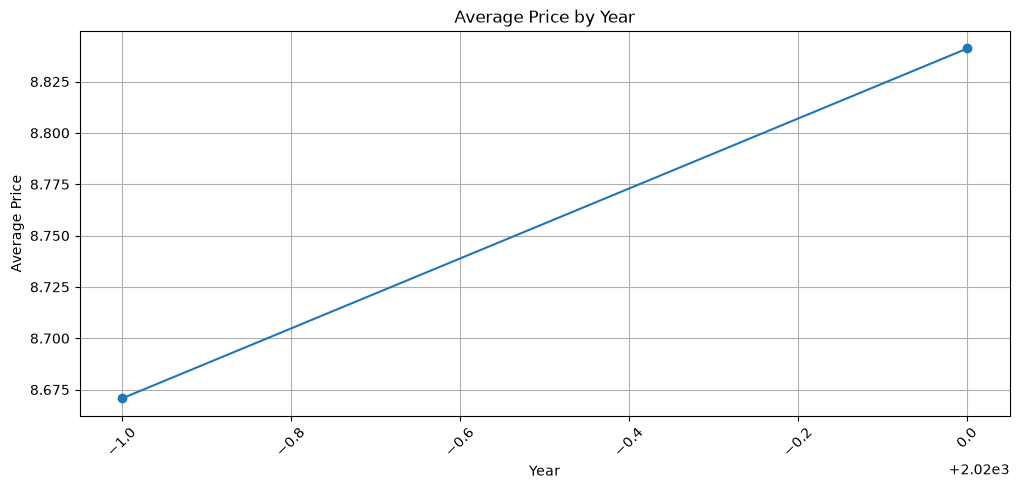

In [46]:


# Calculate average price per month
monthly_avg_price = df.groupby('year')['price'].mean().reset_index()

# Plot
plt.figure(figsize=(12,5))

plt.plot(
    monthly_avg_price['year'],
    monthly_avg_price['price'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Average Price')
plt.title('Average Price by Year')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()